<a href="https://colab.research.google.com/github/sauravv-kunwar/Machine_Learning/blob/main/KMeans_1D_Numerical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# K-Means Clustering — 1D Numerical Example

This notebook solves the exact numerical problem given below, step by step, in simple Python (no libraries like scikit-learn — every step is done manually so you can see how K-Means really works).

**Given dataset:**
$$\{2, 4, 6, 3, 31, 38, 15, 16, 12\}$$

**Initial cluster centers:**
- C1 = 2
- C2 = 16
- C3 = 38

**Number of clusters:** k = 3


## Step 1: Define the dataset and initial centroids

We simply store the data points in a list, and the initial centroids in a dictionary.

In [ ]:
# The given dataset
data = [2, 4, 6, 3, 31, 38, 15, 16, 12]

# Number of clusters
k = 2

# Initial cluster centers (centroids), as given in the problem
centroids = {
    "C1": 2,
    "C2": 38,

}

print("Dataset  :", data)
print("k        :", k)
print("Centroids:", centroids)


Dataset  : [2, 4, 6, 3, 31, 38, 15, 16, 12]
k        : 2
Centroids: {'C1': 2, 'C2': 38}


## Step 2: Function to calculate distance

Since the dataset is 1-dimensional (just single numbers, not points with x,y), the
"Euclidean distance" here is simply the **absolute difference** between two numbers:

$$d(x, c) = |x - c|$$


In [ ]:
def distance(x, c):
    """Distance between a data point x and a centroid c (1D distance)."""
    return abs(x - c)


## Step 3: Assign each point to its nearest centroid

For every data point, we calculate its distance to **all** centroids,
then assign it to the cluster with the **smallest distance**.


In [ ]:
def assign_clusters(data, centroids):
    # Start with empty clusters, e.g. {"C1": [], "C2": [], "C3": []}
    clusters = {c: [] for c in centroids}

    for point in data:
        # Calculate distance of this point from every centroid
        distances = {c_name: distance(point, c_val) for c_name, c_val in centroids.items()}

        # Find the centroid with the minimum distance
        nearest_centroid = min(distances, key=distances.get)

        # Assign the point to that cluster
        clusters[nearest_centroid].append(point)

    return clusters


## Step 4: Recalculate centroids

Once all points are assigned, the new centroid of each cluster
is simply the **average (mean)** of all points in that cluster.

$$c_{new} = \frac{1}{N}\sum_{i=1}^{N} x_i$$


In [ ]:
def recalculate_centroids(clusters):
    new_centroids = {}
    for c_name, points in clusters.items():
        if points:  # only update if the cluster is not empty
            new_centroids[c_name] = round(sum(points) / len(points), 2)
        else:
            new_centroids[c_name] = None
    return new_centroids


## Step 5: Run K-Means (repeat until centroids stop changing)

This is the main loop:
1. Assign every point to the nearest centroid
2. Recalculate the centroids
3. If centroids did not change → **stop** (converged)
4. Otherwise → repeat


In [ ]:
def kmeans(data, centroids, max_iterations=20):
    for iteration in range(1, max_iterations + 1):
        print(f"\n===== Iteration {iteration} =====")
        print("Centroids at start of this iteration:", centroids)

        # Step A: assign points to nearest centroid
        clusters = assign_clusters(data, centroids)
        for c_name, points in clusters.items():
            print(f"  {c_name} (center = {centroids[c_name]}) -> {points}")

        # Step B: recalculate centroids
        new_centroids = recalculate_centroids(clusters)
        print("New centroids:", new_centroids)

        # Step C: check for convergence
        if new_centroids == centroids:
            print("\nCentroids did not change -> K-Means has CONVERGED.")
            return clusters, centroids

        centroids = new_centroids

    return clusters, centroids


## Step 6: Run it on our dataset

In [ ]:
final_clusters, final_centroids = kmeans(data, centroids)

print("\n================ FINAL RESULT ================")
print("Final centroids:")
for c_name, c_val in final_centroids.items():
    print(f"  {c_name} = {c_val}")

print("\nFinal clusters:")
for c_name, points in final_clusters.items():
    print(f"  {c_name}: {points}")



===== Iteration 1 =====
Centroids at start of this iteration: {'C1': 2, 'C2': 38}
  C1 (center = 2) -> [2, 4, 6, 3, 15, 16, 12]
  C2 (center = 38) -> [31, 38]
New centroids: {'C1': 8.29, 'C2': 34.5}

===== Iteration 2 =====
Centroids at start of this iteration: {'C1': 8.29, 'C2': 34.5}
  C1 (center = 8.29) -> [2, 4, 6, 3, 15, 16, 12]
  C2 (center = 34.5) -> [31, 38]
New centroids: {'C1': 8.29, 'C2': 34.5}

Centroids did not change -> K-Means has CONVERGED.

================ FINAL RESULT ================
Final centroids:
  C1 = 8.29
  C2 = 34.5

Final clusters:
  C1: [2, 4, 6, 3, 15, 16, 12]
  C2: [31, 38]


## Step 7 (bonus): Visualize the clusters on a number line


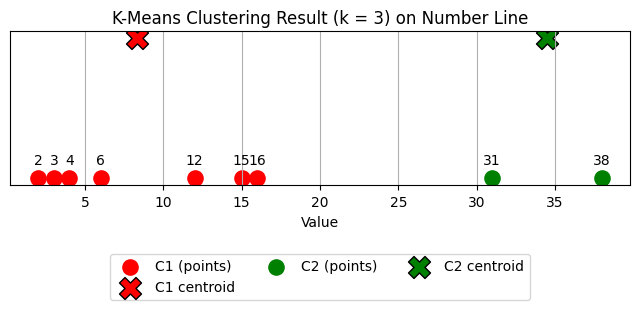

In [ ]:
import matplotlib.pyplot as plt

colors = {"C1": "red", "C2": "green", "C3": "blue"}

plt.figure(figsize=(8, 2))

for c_name, points in final_clusters.items():
    plt.scatter(points, [0] * len(points), color=colors[c_name], s=120, label=f"{c_name} (points)")
    plt.scatter(final_centroids[c_name], 0.05, color=colors[c_name], marker="X", s=250,
                edgecolor="black", label=f"{c_name} centroid")

for point in data:
    plt.annotate(str(point), (point, 0), textcoords="offset points", xytext=(0, 10), ha="center")

plt.yticks([])
plt.xlabel("Value")
plt.title("K-Means Clustering Result (k = 3) on Number Line")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.4), ncol=3)
plt.grid(axis="x")
plt.show()
